<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practicas/sp_2_Maria_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis de datos Modaria II.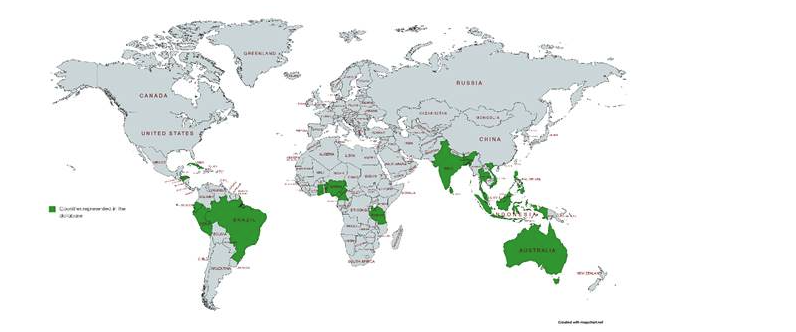

# Preparación de la fuente de datos y librerías

### <span style="color:#2F749F;"><strong>Parte 1. Analisis Univariado</strong></span>
### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir la URL del dataset de la IAEA
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'

# 2. Cargar el archivo directamente desde la red
try:
    df = pd.read_csv(url)
    print(f"Forma del dataset: {df.shape}") # Para ver cuántas filas y columnas tiene
except Exception as e:
    print(f"Hubo un error al cargar los datos: {e}")

# 3. Mostrar las primeras filas para confirmar
print(df.head())

Forma del dataset: (7151, 41)
   Record Element Radionuclide Common name         Latin name Compartment  \
0       1      Cr          NaN      Potato  Solanum tuberosum      Tubers   
1       2      Co          NaN      Potato  Solanum tuberosum      Tubers   
2       3      Ni          NaN      Potato  Solanum tuberosum      Tubers   
3       4      Cu          NaN      Potato  Solanum tuberosum      Tubers   
4       5      Pb          NaN      Potato  Solanum tuberosum      Tubers   

         CR  Uncert._CR  N_CR  Min_CR  ...  OM Exch. K  Exch. Ca  Exch. Mg  \
0  3.60E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
1  1.70E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
2  3.70E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
3  2.50E-01         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
4  1.60E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   

   CEC   pH  QC meas. QC sampl. QC equ

**Parte 1: Análisis Univariado**


Para este analisis univariado, escogí la variable de la concentración del suelo C_soil, en radioecologia el suelo es el reservorio inicial y principal para la bioacumulacion de contaminantes. Es impotante porque antes de entender como estos elemntos llegan a las plantas y a sus compartimientos es importante conocer los valores de la fuente de contaminacion en este caso el suelo.

--- Resultados de Tendencia Central ---
Media:   2338.4465
Mediana: 41.0000
Moda:    0.0500


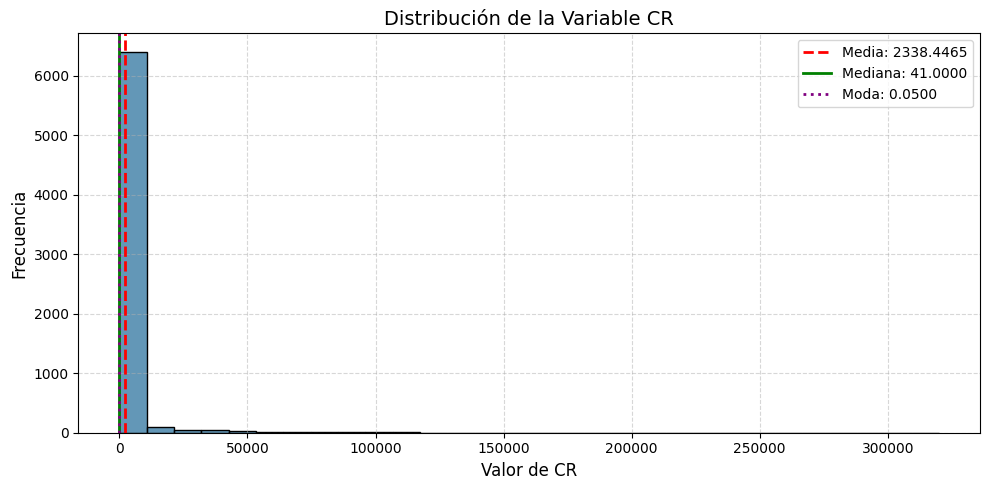

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Limpieza de la variable CR esto es Indispensable para evitar el TypeError
# Quitamos el símbolo '<' y convertimos a número ya que por los limites de deteccin se deja el numero
df['CR_limpia'] = df['C_soil'].astype(str).str.replace('<', '')# este replace es por limites de deteccion de los analsisis no es cero, si tiene un valor muy pequeno por eso se deja solo el valor muy pequeño
df['CR_limpia'] = pd.to_numeric(df['CR_limpia'], errors='coerce')

# Eliminamos valores nulos
cr_data = df['CR_limpia'].dropna()

# 3. Cálculo de medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
# Calculo la moda
moda_res = stats.mode(cr_data, keepdims=True)
moda = moda_res.mode[0]

# Imprimir resultados
print("--- Resultados de Tendencia Central ---")
print(f"Media:   {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Moda:    {moda:.4f}")

# 4. Gráfico en Escala Lineal (Igual al ejemplo de los helados)
plt.figure(figsize=(10, 5))

# Histograma normal
sns.histplot(cr_data, bins=30, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.4f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.4f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.4f}')

# Configuración visual
plt.title("Distribución de la Variable CR", fontsize=14)
plt.xlabel("Valor de CR", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()



Esta gráfica presenta un sesgo positivo muy marcado. La diferencia entre la media que es 2338.45 y la mediana de 41.00 es casi 60 veces mayor, lo que evidencia una asimetría muy pronunciada y la presencia de valores extremadamente altos,que no son errores de medición, sino que reflejan la propia naturaleza heterogénea de los datos.
La variable C_soil combina radionúclidos y metales pesados con comportamientos geoquímicos y biológicos muy distintos. Esta naturaleza de los datos y la presencia pueden estar ocultando los patrones reales de los datos.  
De esta gráfica puedo tener una hipotesis y  es que la variabilidad extrema podría deberse no solo a las concentraciones de metales pesados, sino también a radionúclidos con mayor disponibilidad, como el potasio-40 (K-40). Este radionúclido natural tiende a presentar valores más altos en suelos con mayor disponibilidad de potasio total, y este puede ser influenciado por factores como un ph superior a 6 y un contenido de arcilla que pueden favorecer la fijacion y liberacion lenta del suelo a la planta, caracteristicas geologicas inherentes de los suelos pueden estar gobernando la tramicion de este radionucleido a la pnata, asi que debido a la naturlza de este radionucleido y a la precensia dde metales pesados que pueden estar elevando la media debido a las concetraciones elevadas de estos elementos presentes, he decidido enfocarme exclusivamente en el Cs-137 para el analisis univariado. Esta elección  se basa en su relevancia radiológica, ya uqe me perimte evaluar riesgos ambientales ya que este radionucleido es antropogenico y surge principalmente de activiades humanas como pruebas nucleares atmosféricas (años 1950-1960), accidentes nucleares (ej. Chernobyl en 1986 o Fukushima en 2011) y fugas de instalaciones atómicas. Esto significa que su presencia en el suelo no depende de la geología natural, sino de deposiciones históricas y contaminaciones puntuales, lo que permite un análisis enfocado en procesos de contaminación antrópica, sin interferencias de fondos geológicos variables.
Además, el Cs-137 destaca por su alta movilidad y capacidad para entrar en la cadena trófica de manera eficiente, este puede ser absorbido facilmente por las raíces para depositarse en los diferentes compartimientos de las plantas. Su semivida de 30 años lo hace eestar presente durante la vida de muchos oprganismos, aumentando el riesgo de exposición crónica y efectos radiológicos como daño celular o cáncer. Esta vía de entrada trófica lo convierte en un marcador clave para estudios de riesgo.

--- Estadísticas para Cs-137 (n=320) ---
Media:   1276.0617
Mediana: 4.5500
Moda:    2.4000


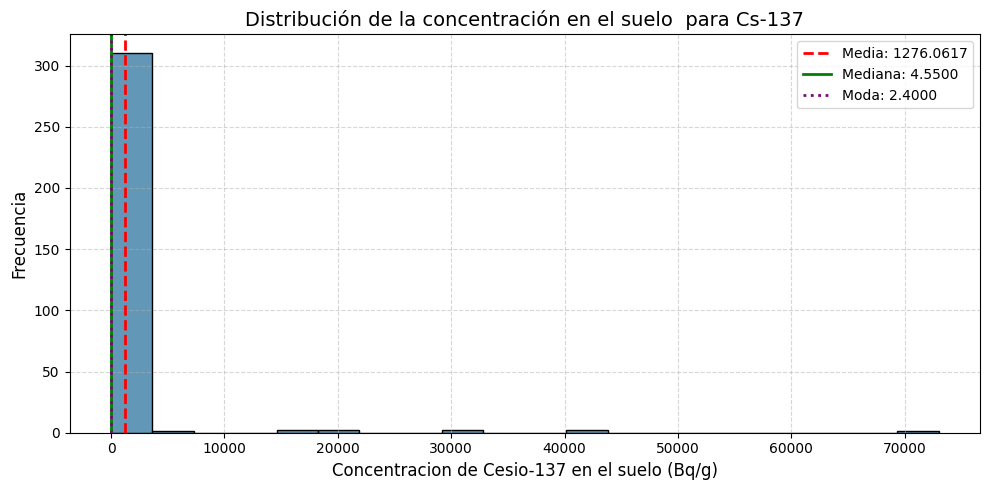

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
# Usamos .copy() para evitar advertencias al limpiar los datos después
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable CR en el set filtrado
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Quitar nulos para los cálculos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
moda_res = stats.mode(cr_data, keepdims=True)
moda = moda_res.mode[0]

# Imprimir resultados
print(f"--- Estadísticas para Cs-137 (n={len(cr_data)}) ---")
print(f"Media:   {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Moda:    {moda:.4f}")

# 5. Gráfico (Escala Lineal)
plt.figure(figsize=(10, 5))

# Histograma
sns.histplot(cr_data, bins=20, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.4f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.4f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.4f}')

plt.title("Distribución de la concentración en el suelo  para Cs-137", fontsize=14)
plt.xlabel("Concentracion de Cesio-137 en el suelo (Bq/g)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Al filtrar el Cs-137, la grafica muestra  que el comportamiento de los datos no cambia, se tienen valores maximos que estan apotando a la media. Esto muestra que la variabilidad de los datos no era solo por mezclar elementos (metales y radinucleidos), sino que es una distribucion tipica de los contaminates en el suelo en ambientes tropicales.
La mediana de 4.55 Bq/g representa una concentración típica de la mayoría de las muestras, mientras que el promedio de $1276$ está sobreestimada por unos pocos puntos con cincetraciones elevadas  (cerca de $70,000$).
Esta acumulación extrema en puntos específicos (outliers) se pude explicar a eventos de Deposición Localizada que a diferencia de los minerales naturales que su ditribucion depende de factores geologicos y de rocas madres que emanna estos radinucleidos, el Cs-137 llega al suelo por lluvia radiactiva (fallout). Las precipitaciones intensas en zonas tropicales pueden lavar el cesio de un lugar y concentrarlo en depresiones del terreno o cuencas, creando "puntos calientes" o hotspots, adicionalmente, el Cesio se queda atrapado muy fuertemente en ciertos tipos de arcilla (como la illita). Si una muestra tiene mucha arcilla y otra es más arenosa, la diferencia de concentración será masiva aunque estén cerca.

### <span style="color:#2F749F;"><strong>Parte 2: Cálculo de medidas de dispersión</strong></span>

1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

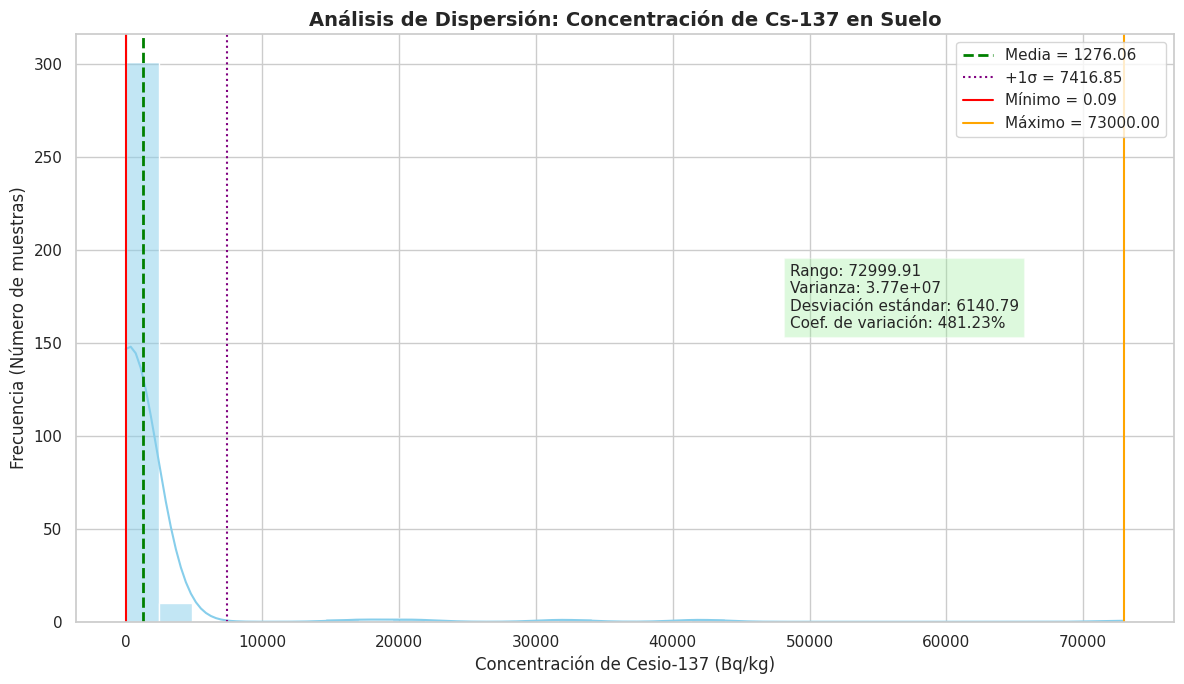

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable (C_soil)
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Definir la variable final libre de nulos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
moda = stats.mode(cr_data, keepdims=True).mode[0]

# --- NUEVO: Cálculo de medidas de dispersión con TUS datos ---
minimo = np.min(cr_data)
maximo = np.max(cr_data)
rango = maximo - minimo
varianza = np.var(cr_data, ddof=1) # ddof=1 para varianza muestral
desviacion = np.std(cr_data, ddof=1)
coef_var = (desviacion / media) * 100

# --- Visualización de Dispersión para Cs-137 ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Histograma de los datos filtrados
sns.histplot(cr_data, bins=30, kde=True, color='skyblue')

# Líneas de dispersión
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
# La línea -1σ la dibujo solo si es mayor que el mínimo para que no se salga del gráfico
if (media - desviacion) > minimo:
    plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')

plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo:.2f}')
plt.axvline(maximo, color='orange', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo:.2f}')

# Configuración de etiquetas
plt.title("Análisis de Dispersión: Concentración de Cs-137 en Suelo", fontsize=14, fontweight='bold')
plt.xlabel("Concentración de Cesio-137 (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia (Número de muestras)", fontsize=12)
plt.legend(loc='upper right')

# Recuadro con medidas de dispersión
# Usamos transform=plt.gca().transAxes para que el cuadro se ubique relativo a la imagen (0 a 1)
# y no dependa de los valores gigantes de los datos.
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2e}\n"  # Usamos notación científica para la varianza porque será muy grande
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}%"
)

# Ubicamos el texto en la parte media-derecha del gráfico
plt.text(0.65, 0.5, texto, transform=plt.gca().transAxes,
         bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=11)

plt.tight_layout()
plt.show()


 Al analizar las medidas de dispersión de la concentración de Cs-137, el rango de $72,999.91$ Bq/kg revela una desigualdad total entre los datos, donde suelos casi limpios con concentraciones $0.09$ Bq/kg coexisten con puntos de contaminación crítica de $73,000$ Bq/kg, confirmando que la presencia de este radionúclido no es uniforme en el terreno. Esta dispersión se refleja en una varianza de $3.77 \times 10^7$, un valor que indica que los datos están  alejados del "centro" o promedio ($1,276.06$), esto significa que la media no es un valor que represente lo que realmente hay en el campo, sino un cálculo matemático sobrestimado por los datos atipicos. La desviación estándar de $6,140.79$, al ser casi cinco veces más grande que la media, confirma que el promedio no es una medida confiable, ya que la distancia común entre cualquier muestra y ese valor central es tan grande que la media no logra resumir la realidad del suelo.
Finalmente, el coeficiente de variación del $481.23\%$ muestra que la mayoría del terreno tiene niveles bajos y solo unos pocos puntos concentran casi toda la radiactividad, lo cual se explica porque el Cs-137 llegó por lluvia y el agua en climas tropicales lo arrastró de las laderas para amontonarlo en las zonas bajas, creando "puntos calientes" (hotspots) que rompen cualquier intento de ver los datos como algo parejo.

### <span style="color:#2F749F;"><strong>Parte 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal

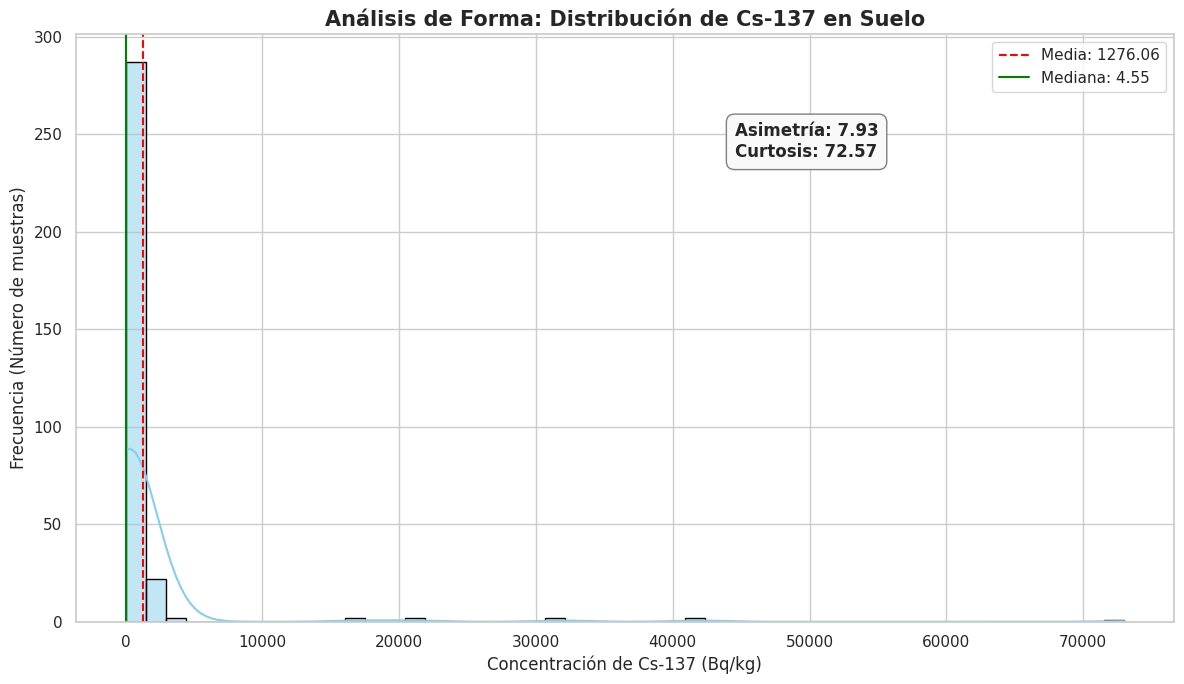

Resultados para Cs-137:
Asimetría: 7.93
Curtosis: 72.57


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 1. Cargar el dataset directamente desde la fuente de la IAEA
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable de concentración en suelo (C_soil)
# Eliminamos caracteres de límite de detección (<) y convertimos a número
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Definir la serie final eliminando valores nulos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Cálculo de medidas de forma
asimetria_val = skew(cr_data)
curtosis_val = kurtosis(cr_data, fisher=True)

# 5. Visualización siguiendo el estilo de la profesora
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Histograma con KDE (Línea de densidad)
ax = sns.histplot(cr_data, kde=True, color='skyblue', bins=50, edgecolor="black")

# Personalización de títulos y etiquetas
plt.title("Análisis de Forma: Distribución de Cs-137 en Suelo", fontsize=15, fontweight='bold')
plt.xlabel("Concentración de Cs-137 (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia (Número de muestras)", fontsize=12)

# Cuadro de texto con los resultados estadísticos
plt.text(0.6, 0.85,
         f"Asimetría: {asimetria_val:.2f}\nCurtosis: {curtosis_val:.2f}",
         transform=ax.transAxes,
         fontsize=12,
         verticalalignment='top',
         fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

# Añadir líneas para media y mediana para reforzar el análisis anterior
plt.axvline(cr_data.mean(), color='red', linestyle='--', label=f'Media: {cr_data.mean():.2f}')
plt.axvline(cr_data.median(), color='green', linestyle='-', label=f'Mediana: {cr_data.median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir resultados en consola para verificar
print(f"Resultados para Cs-137:")
print(f"Asimetría: {asimetria_val:.2f}")
print(f"Curtosis: {curtosis_val:.2f}")

El análisis de la forma de la distribución muestra resultados que confirman la naturaleza atípica del Cs-137 en este estudio. Los coeficientes confirman que la distribución del Cs-137 se aleja de los parámetros de una distribución normal (donde ambos valores serían 0). La Asimetría de 7.93 indica un sesgo positivo pronunciado, lo que significa que el peso de la distribución recae en los valores bajos, mientras que la "cola" de la derecha se extiende hacia las concentraciones máximas. Este valor explica por qué la mediana ($4.55$ Bq/kg) es menor que la media ($1276.06$ Bq/kg), demostrando que el promedio está sobreestimado por la influencia de los valores extremos.
La Curtosis de 72.57 define una distribución leptocúrtica, caracterizada por una concentración masiva de datos en un rango estrecho y una frecuencia de valores atípicos. En términos radioecológicos, estas métricas prueban que el Cs-137 no se distribuye de forma aleatoria o uniforme, sino que su presencia en el suelo está gobernada por procesos de acumulación específica o hotspots.


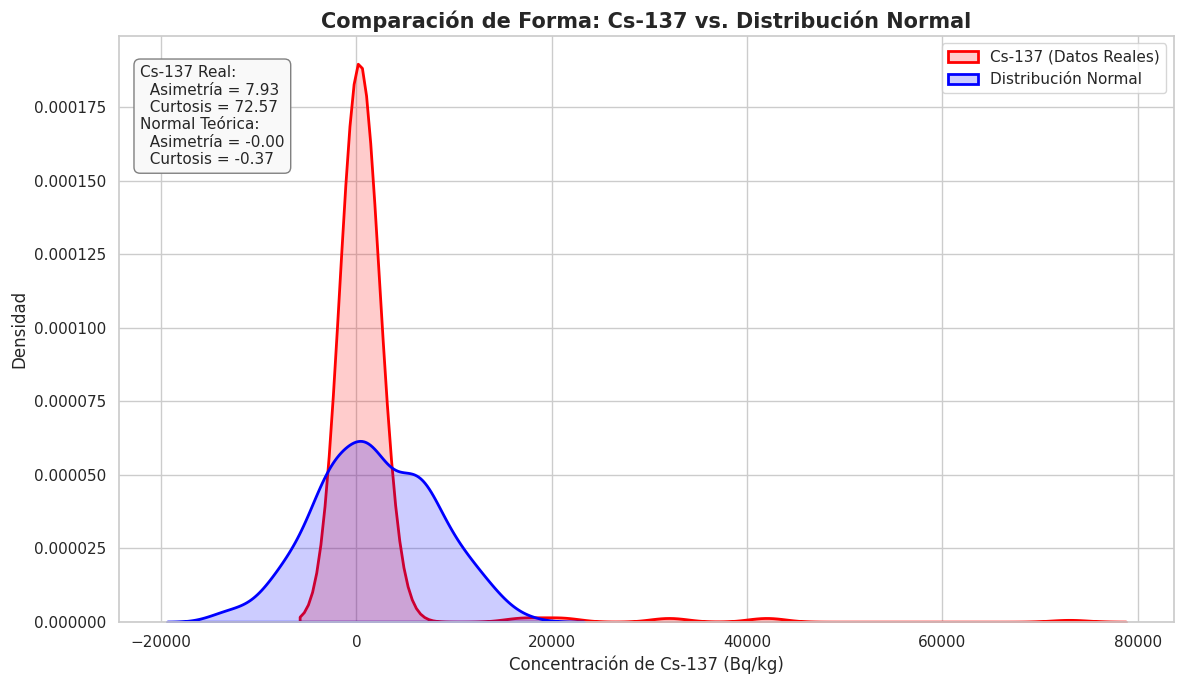

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm

# 1. Cargar y limpiar datos (proceso que ya tienes)
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['C_soil'].astype(str).str.replace('<', ''), errors='coerce')
cr_data = df_filtered['CS_limpia'].dropna()

# 2. Crear una distribución normal teórica para comparar
# Usamos la misma media y desviación de tus datos para ver la diferencia de forma
mu, std = cr_data.mean(), cr_data.std()
normal_teorica = np.random.normal(mu, std, size=len(cr_data))

# 3. Cálculo de métricas
metrics = {
    'Cs-137 Real': {'data': cr_data, 'color': 'red', 'label': 'Cs-137 (Datos Reales)'},
    'Normal Teórica': {'data': normal_teorica, 'color': 'blue', 'label': 'Distribución Normal'}
}

for key in metrics:
    datos = metrics[key]['data']
    metrics[key]['skew'] = skew(datos)
    metrics[key]['kurtosis'] = kurtosis(datos, fisher=True)

# 4. Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

for key in metrics:
    sns.kdeplot(metrics[key]['data'], label=metrics[key]['label'],
                color=metrics[key]['color'], linewidth=2, fill=True, alpha=0.2)

# Anotaciones (Estilo de la profesora)
texto = "\n".join([
    f"{key}:\n  Asimetría = {metrics[key]['skew']:.2f}\n  Curtosis = {metrics[key]['kurtosis']:.2f}"
    for key in metrics
])

plt.text(0.02, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor='#f9f9f9', edgecolor="gray"))

plt.title('Comparación de Forma: Cs-137 vs. Distribución Normal', fontsize=15, fontweight='bold')
plt.xlabel('Concentración de Cs-137 (Bq/kg)')
plt.ylabel('Densidad')
plt.legend(loc="upper right")

# Ajustar escala si los hotspots no dejan ver la curva (opcional)
# plt.xlim(-1000, 15000)

plt.tight_layout()
plt.show()

Para evaluar la naturaleza de la dispersión, se generó una distribución normal teórica (curva azul) utilizando la media ($\mu = 1,276.06$) y la desviación estándar ($\sigma = 6,140.79$) calculadas a partir del set de datos; este modelo representa el escenario ideal donde el Cs-137 se hubiera depositado y mantenido de forma homogénea en el terreno, presentando una asimetría de cero. Al contrastar este modelo con la distribución real (curva roja), se evidencia que los datos no siguen un patrón gaussiano, sino que presentan una morfología leptocúrtica extrema con una curtosis de $72.57$. Mientras la campana azul sugiere una probabilidad distribuida de forma suave, la curva roja muestra un pico excesivamente estrecho y elevado cerca del origen, indicando que la gran mayoría de las muestras poseen concentraciones mínimas. Sin embargo, la asimetría de $7.93$ en los datos reales genera una "cola" o sesgo hacia la derecha que el modelo normal es incapaz de capturar, confirmando que la presencia de hotspots o puntos críticos de contaminación rompe la simetría teórica. Esta comparación visual demuestra que la realidad del terreno está gobernada por valores atípicos que invalidan el uso del promedio como valor representativo y exigen un análisis basado en la heterogeneidad espacial

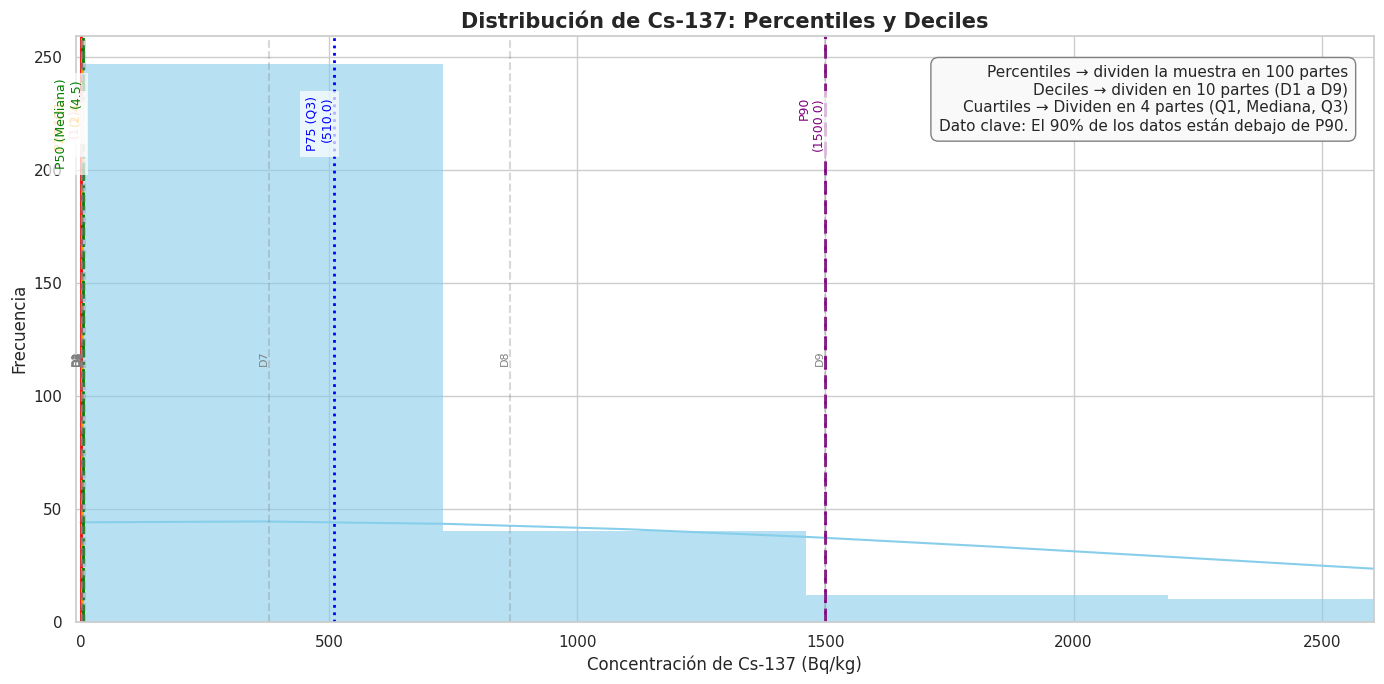

--- Tabla de Posición ---
P10: 1.10 Bq/kg
P25 (Q1): 2.40 Bq/kg
P50 (Mediana): 4.55 Bq/kg
P75 (Q3): 510.00 Bq/kg
P90: 1500.00 Bq/kg


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aseguramos que los datos estén cargados (cr_data)
# (Asumiendo que cr_data ya está definido de los pasos anteriores)

# Estilo visual
sns.set_theme(style="whitegrid")

# 2. Cálculo de percentiles clave para Cs-137
percentiles = {
    'P10': {'valor': np.percentile(cr_data, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(cr_data, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(cr_data, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(cr_data, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(cr_data, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# 3. Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(cr_data, i * 10) for i in range(1, 10)}

# 4. Visualización
plt.figure(figsize=(14, 7))

# Nota: Usamos bins=100 porque tus datos tienen mucha dispersión
sns.histplot(cr_data, kde=True, color='skyblue', bins=100, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    # Ajustamos la altura del texto para que no se amontone
    plt.text(props['valor'], plt.ylim()[1]*0.85, f"{etiqueta}\n({props['valor']:.1f})",
             rotation=90, color=props['color'], fontsize=9,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.45, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

# Cuadro de texto explicativo (estilo profe)
texto = (
    "Percentiles → dividen la muestra en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Dividen en 4 partes (Q1, Mediana, Q3)\n"
    "Dato clave: El 90% de los datos están debajo de P90.")

plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

# Limitamos el eje X para que los percentiles sean visibles
# (Si no, el hotspot de 73,000 los dejaría todos pegados a la izquierda)
plt.xlim(-10, np.percentile(cr_data, 95))

plt.title("Distribución de Cs-137: Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Concentración de Cs-137 (Bq/kg)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Imprimir tabla de valores para el análisis
print("--- Tabla de Posición ---")
for p, info in percentiles.items():
    print(f"{p}: {info['valor']:.2f} Bq/kg")

La visualización de los percentiles confirma  variabilidad  en la distribución de los datos. El hecho de que el 50% de las muestras (Mediana) se sitúe en apenas 4.55 Bq/kg, mientras que el 90% (P90) se incremente hasta los 1,500 Bq/kg, evidencia una distribución con una cola derecha debido a los outliers y valores con altas conetraciones.
Se observa una brecha de magnitud entre la base de la muestra y los valores extremos: el P90 es más de 300 veces superior a la mediana. La alta densidad de deciles (D1 a D6) acumulados cerca del origen indica que la gran mayoría de las observaciones presentan concentraciones bajas.
El amplio intervalo hacia la derecha representa la cola derecha con los valores elevados de la distribución, donde se ubican los hotspots.
 En conclusión, los percentiles demuestran que el valor de la media ($1,276.06$ Bq/kg) solo se alcanza a partir del percentil 85, lo que confirma que el promedio no es una medida de tendencia central representativa para la mayor parte del conjunto de datos, sino que está sesgado por el 15% de las muestras con mayor actividad.

# Conclusion Análisis Univariado
El análisis univariado ha permitido identificar que el Cs-137 presenta una distribución con una variabilidad extrema y una presencia dominante de puntos críticos (hotspots). Sin embargo, los resultados demuestran que este enfoque estadístico es insuficiente para cumplir con los objetivos generales de la investigación por tres razones fundamentales:

Ocultamiento de la tendencia central: Debido al sesgo provocado por los valores atípicos, es imposible caracterizar el comportamiento de las muestras con concentraciones bajas, que representan la mayor parte del terreno estudiado.

Inconsistencia del promedio: La media aritmética, al estar influenciada por la "cola pesada" de la distribución, pierde su valor como descriptor representativo, impidiendo un análisis comparativo fiable con otros radionucleidos.

Necesidad de procesamiento avanzado: Se concluye que un análisis descriptivo básico es limitante si no se aplican técnicas de transformación de datos (como escalas logarítmicas) o la segmentación de valores atípicos para normalizar la muestra.

En definitiva, aunque el análisis univariado confirma la heterogeneidad del suelo, resulta insuficiente para entender las relaciones causales del Cs-137. Por tanto, es imperativo transitar hacia un análisis bivariado y multivariado que permita cruzar estos datos con otras variables fisicoquímicas, buscando patrones que la estadística descriptiva simple no logra revelar.

# Analisis Bivariado

### <span style="color:#2F749F;"><strong>Parte 4: Coeficiente de Pearson</strong></span>
Utilizamos el Coeficiente de Pearson ($r$) para analizar la relación entre el Contenido de Arcilla (Clay) y la Capacidad de Intercambio Catiónico (CEC), ya que ambas son variables numéricas continuas que representan propiedades críticas del suelo en ambientes tropicales.Esta elección es fundamental para resolver nuestra pregunta de investigación porque la arcilla es el principal componente del suelo encargado de retener metales pesados y radionúclidos. Según la definición, Pearson evalúa la 'fuerza lineal'; por tanto, este análisis nos permite comprobar si existe un aumento constante y proporcional en la capacidad de retención del suelo a medida que aumenta la fracción de arcilla. Determinar esta relación lineal es el primer paso para entender por qué ciertos suelos tropicales acumulan más radionúclidos que otros, estableciendo la base fisicoquímica de la disponibilidad de estos elementos para las plantas.

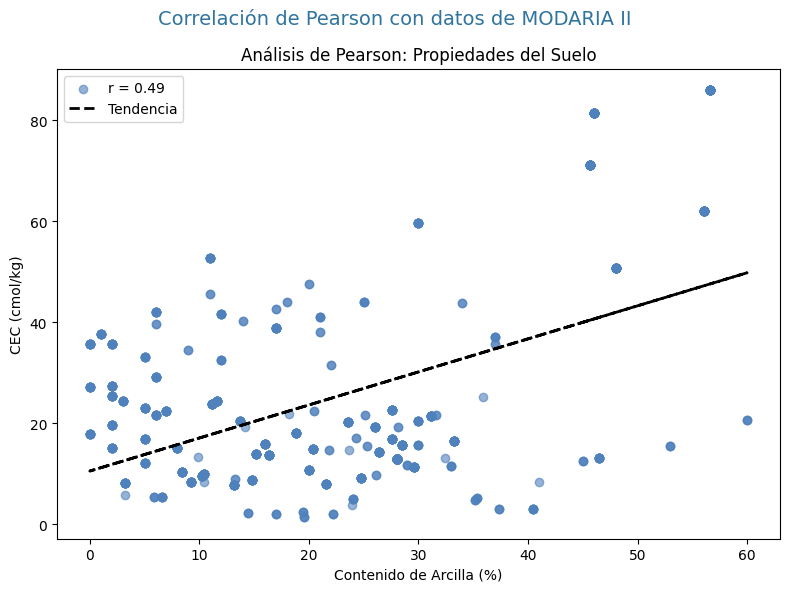

Resultados del análisis:
Variable X: Clay (Arcilla)
Variable Y: CEC (Capacidad de Intercambio Catiónico)
Coeficiente r de Pearson: 0.4923


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Carga del dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Limpieza de datos (Variables para Pearson)
# Usaremos Clay (Arcilla) y CEC (Capacidad de intercambio)
df['Clay'] = pd.to_numeric(df['Clay'], errors='coerce')
df['CEC'] = pd.to_numeric(df['CEC'], errors='coerce')

# Filtramos nulos para que Pearson no de error
df_pearson = df[['Clay', 'CEC']].dropna()

# 3. Cálculo del coeficiente de Pearson
r, _ = pearsonr(df_pearson['Clay'], df_pearson['CEC'])

# 4. Función de visualización (Estilo exacto de la profe)
def plot_corr_real(ax, x, y, r, title, color, xlabel, ylabel):
    ax.scatter(x, y, alpha=0.6, color=color, label=f"r = {r:.2f}")

    # Línea de tendencia (Ajuste lineal)
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x + b, color="black", linewidth=2, linestyle="--", label="Tendencia")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

# 5. Generar la gráfica
fig, ax = plt.subplots(figsize=(8, 6))

plot_corr_real(
    ax,
    df_pearson['Clay'],
    df_pearson['CEC'],
    r,
    "Análisis de Pearson: Propiedades del Suelo",
    "#4F81BD", # Color azul del ejemplo de la profe
    "Contenido de Arcilla (%)",
    "CEC (cmol/kg)"
)

plt.suptitle("Correlación de Pearson con datos de MODARIA II", fontsize=14, color="#2F749F")
plt.tight_layout()
plt.show()

# Resumen para tu tarea
print(f"Resultados del análisis:")
print(f"Variable X: Clay (Arcilla)")
print(f"Variable Y: CEC (Capacidad de Intercambio Catiónico)")
print(f"Coeficiente r de Pearson: {r:.4f}")

El coeficiente de Pearson obtenido es 0.4923. Según la escala de Pearson, esto se clasifica como una correlación positiva moderada.

Dirección: Es positiva. Esto significa que a medida que aumenta el porcentaje de arcilla en el suelo, la Capacidad de Intercambio Catiónico (CEC) también tiende a aumentar.

Fuerza: Moderada. Los puntos no están pegados a la línea (hay dispersión), lo cual es normal en datos ambientales, pero la tendencia ascendente es clara y visible.
Los resultados muestran que el Contenido de Arcilla explica una parte importante de la variabilidad de la CEC en estos suelos tropicales. Para nuestra investigación, esto es clave porque la CEC representa la 'capacidad de carga' del suelo; es decir, cuántos radionúclidos y metales pesados puede retener el suelo en sus partículas.

Al confirmar una correlación moderada positiva, podemos inferir que los suelos con mayores texturas arcillosas ofrecen más sitios de unión para los radionúclidos. Esto sugiere que la arcilla actúa como un factor regulador que controla qué tanta cantidad de metales están 'disponibles' en el suelo antes de ser absorbidos por las raíces de las plantas tropicales.
Se observa cierta dispersión en los datos, lo que sugiere que, aunque la arcilla es importante, existen otras propiedades del suelo (como la Materia Orgánica - OM) que también influyen en la CEC. Sin embargo, la tendencia lineal confirmada por Pearson valida que la arcilla es un predictor fundamental en el modelo de absorción de este estudio.

### <span style="color:#2F749F;"><strong>Parte 4: Coeficiente de Spearman</strong></span>
